---
title: "The Danckwerts boundary conditions, and Wehner & Wilhelm's proof of them"
description: "Two conditions close the axial-dispersion reactor: a flux balance at the inlet that makes the concentration jump, and a zero gradient at the outlet. Both against the closed form, both broken on purpose, and the naive inlet's error measured across four decades of Peclet number."
categories: [sec:A, struct:S4, tier:T0, data:tier6, phase:liquid]
date: 2026-08-02
---

# The Danckwerts boundary conditions, and Wehner & Wilhelm's proof of them

**Catalog ID:** `A2.1` (covers `A2.2`) · **Structure:** `S4` (1-D convection–dispersion–reaction) · **Tier:** T0

A tubular reactor with axial dispersion is a second-order equation, so it needs
two boundary conditions — and the obvious pair is wrong. Setting
$c(0) = c_{\mathrm{in}}$ over-predicts the outlet concentration by 50 % at the
Peclet number Wehner and Wilhelm chose for their own figure, and by 179 % at
$\mathrm{Pe} = 0.1$; as $\mathrm{Pe} \to 0$ it predicts **no conversion at all**,
in a limit that has to be a stirred tank.

The right pair is Danckwerts' (1953): a **flux** balance at the inlet, which
makes the concentration drop across the bed entrance — discontinuously in the
closed-vessel idealisation, and Wehner & Wilhelm say in as many words that the
discontinuity is *"not necessarily correct"* — and a **zero gradient** at the
outlet. Danckwerts justified the second by intuition; Wehner and Wilhelm (1956)
derived both three years later by putting the reactor between an inlet pipe and
an outlet pipe and letting each run to infinity. Their fuller picture keeps $f$
continuous at $z=0$; the section on their three-section model measures the
difference and reconciles the two.

## Background

**Why this page exists twice over.** The outward-normal boundary-condition
convention is the single most common `pymrm` error, and this is its canonical
worked case: an inlet condition whose sign matters, an outlet condition whose
sign does not, a closed-form answer to check both against, and a wrong version
whose error is large enough to see.

**Why one page and not two.** The catalog lists `A2.1` (Danckwerts) and `A2.2`
(Wehner–Wilhelm) separately. They are built here as one page because Wehner &
Wilhelm's central result *is* Danckwerts' result: their eq. (20) for the reaction
section is algebraically identical to Danckwerts' eq. (33), and they say so on
their page 91 — *"The solution for the reaction section (equation 20) is
identical with that of DANCKWERTS."* A separate `A2.2` page would have to
validate against the same closed form this page already validates against, which
is the situation that made `J3.3` `covered` rather than built. What Wehner &
Wilhelm add is not a second model but the **justification** of the first, and a
boundary condition and its justification are one result. The scope decision, and
the argument against it, are recorded in `queue_cases/A2.1.yaml`.

**The physical problem.** Fluid at mean velocity $u$ carries a reactant through
a packed bed of length $L$. Longitudinal mixing — eddies, wall effects,
channelling, molecular diffusion — is lumped into an apparent axial diffusivity
$D$, which is what [`A2.3`](../A2.3-taylor-aris-dispersion/) computes from first
principles for laminar flow in a tube. A first-order reaction consumes the
reactant inside the bed. The question is what happens at the two ends.

## The published model

### Danckwerts (1953), Section "Flow through beds of solids"

His steady-state balance on a slice $\mathrm{d}y$ (**his eq. 30**):

$$
\frac{\mathrm{d}^{2}c}{\mathrm{d}y^{2}} - \frac{u}{D}\frac{\mathrm{d}c}{\mathrm{d}y}
- \frac{kc}{D} = 0 .
$$

His words for the inlet, quoted: *"The concentration of reactant in the entering
stream is $c^{*}$; owing to diffusion the concentration just within the entrance
of the reactor, at $y = 0$, is less than $c^{*}$. The following boundary
condition expresses the fact that the rate at which reactant is fed to the
reactor is equal to the rate at which it crosses plane $y = 0$ by combined flow
and diffusion."* (**his eq. 31**):

$$
u\,c^{*} = u\,c - D\,\frac{\mathrm{d}c}{\mathrm{d}y}, \qquad y = 0 .
$$

At the outlet he writes the same flux balance with $f c^{*}$ the exit-stream
concentration (unnumbered), then argues: *"Now if $\mathrm{d}c/\mathrm{d}y$ were
negative, the concentration in the exit stream would be greater than that at the
end of the packing. If $\mathrm{d}c/\mathrm{d}y$ were positive the concentration
would pass through a minimum somewhere in the reactor and then rise towards the
downstream end. **Intuition suggests** that neither of these situations can
arise, so that the boundary condition must be"* (**his eq. 32**):

$$
\frac{\mathrm{d}c}{\mathrm{d}y} = 0, \qquad y = L .
$$

**His closed-form solution** (eq. 33), with $a = \sqrt{1 + 4kD/u^{2}}$:

$$
\frac{c}{c^{*}} = \exp\!\left(\frac{uy}{2D}\right)
\left[\frac{2(1+a)\exp\frac{ua}{2D}(L-y) - 2(1-a)\exp\frac{ua}{2D}(y-L)}
{(1+a)^{2}\exp\frac{uaL}{2D} - (1-a)^{2}\exp\frac{-uaL}{2D}}\right],
$$

and the exit value, $(1-f)$ being the fraction reacted (**his eq. 34**):

$$
1 - f = 1 - \frac{4a}
{(1+a)^{2}\exp\frac{-uL}{2D}(1-a) - (1-a)^{2}\exp\frac{-uL}{2D}(1+a)} .
$$

He then states three limits, **eqs. (35), (36) and (37)**:

$$
1-f = 1 - \exp\frac{-kL}{u}\ \ (D\to 0),\qquad
1-f = \frac{kL}{u+kL}\ \ (D\to\infty),\qquad
1-f \approx 1 - \left(1 + \frac{k^{2}DL}{u^{3}}\right)\exp\frac{-kL}{u}\ \ (\text{small } D),
$$

*"From this it can be seen that the effect of diffusion is to decrease the
fractional conversion compared to that for piston-flow, but that the effect will
be negligible provided $k^{2}DL/u^{3} \ll 1$, or $[\ln f]^{2}D/Lu \ll 1$."*

### Wehner & Wilhelm (1956)

They non-dimensionalise with $\mathrm{Pe} = Lu/D$, $R = kL/u$, $z = y/L$, and $f$
the fraction of reactant remaining (their eq. 1):

$$
\frac{1}{\mathrm{Pe}}\frac{\mathrm{d}^{2}f}{\mathrm{d}z^{2}}
- \frac{\mathrm{d}f}{\mathrm{d}z} - Rf = 0 .
$$

They restate Danckwerts' conditions as their **eqs. (2) and (3)**:

$$
f(0^-) = 1 = f(0^+) - \frac{1}{\mathrm{Pe}}\frac{\mathrm{d}f}{\mathrm{d}z}(0^+),
\qquad \frac{\mathrm{d}f}{\mathrm{d}z}(1) = 0,
$$

and note that Hulburt's alternative, $f(0^-) = f(0^+) = 1$, *"neglects the
diffusion directly within the reactor"*.

**Their own caveat on the inlet jump, which cuts against the picture above.** Of
Danckwerts' inlet condition they write, on their p. 90: *"There is a
discontinuity at this boundary as reported which will be shown later to be **not
necessarily correct**."* And on p. 91: *"The boundary condition as written by
DANCKWERTS is the equivalent of the step function mentioned above since he did
not include the term $(1/\mathrm{Pe}_a)\,\mathrm{d}f(z<0)/\mathrm{d}z$."* In
their own three-section model $f$ is **continuous** at $z = 0$: the fall from 1
to $f(0)$ is spread over the fore section with decay length $1/\mathrm{Pe}_a$
(their eq. 19), and Danckwerts' step is only its $\mathrm{Pe}_a \to \infty$
limit. The vertical dotted drop in the first figure below is therefore the
closed-vessel *idealisation*, not a claim about the fluid; check 3 measures how
far the real fall is spread, and how it collapses to a step as
$\mathrm{Pe}_a$ grows.

**Their model** puts the bed between a fore section $z<0$ and an after section
$z>1$, each with its own Peclet group, each stretching to infinity, with six
boundary conditions: $f(-\infty) = 1$; $f(\infty)$ finite; continuity of $f$ and
of the total flux at $z = 0$ and $z = 1$. Solving all three sections at once
gives (their eqs. 19–22), with $a = \sqrt{1 + 4R/\mathrm{Pe}_b}$:

$$
\frac{1-f}{1-f(0)} = \exp(\mathrm{Pe}_a z),\quad z\le 0;
\qquad
f = f(1) = 2 a g_0 \exp(\mathrm{Pe}_b/2) = \text{constant},\quad z>1;
$$

$$
f = g_0\exp\!\left(\frac{\mathrm{Pe}_b z}{2}\right)
\left\{(1+a)\exp\frac{a\mathrm{Pe}_b(1-z)}{2} - (1-a)\exp\frac{a\mathrm{Pe}_b(z-1)}{2}\right\},
\quad 0\le z\le 1,
$$

$$
g_0 = \frac{2}{(1+a)^{2}\exp\frac{a\mathrm{Pe}_b}{2} - (1-a)^{2}\exp\frac{-a\mathrm{Pe}_b}{2}},
\qquad
f(0) = g_0\left\{(1+a)\exp\frac{a\mathrm{Pe}_b}{2} - (1-a)\exp\frac{-a\mathrm{Pe}_b}{2}\right\}.
$$

**Three of their conclusions are what this page tests.**

1. The reaction-section profile *"does not depend upon conditions in the fore
   section"*, and *"the value of the diffusivity in the after section does not
   enter into the results."*
2. The after section is flat, so *"in the boundary condition equation (13) the
   last term is zero … it follows immediately that $\mathrm{d}f(1-)/\mathrm{d}z
   = 0$. In effect, the boundary condition at $z = +\infty$ is drawn to the end
   of the reaction bed."* Danckwerts' intuition, derived.
3. *"The HULBURT solution may be arrived at by normalization through division of
   the DANCKWERTS solution by $f(0)$. Although convenient … the solution is not
   consistent with the limit of a stirred reactor with infinite diffusivity in
   the reaction section."* That sentence is the closed form for the error made by
   the naive Dirichlet inlet, and it is what Section "the wrong inlet condition"
   below measures.

## Parameters and assumptions

**Assumptions**, as both papers state them: steady state; constant velocity, so
no volume change on reaction (*"It is assumed that there is no volume change
during reaction"* — Wehner & Wilhelm p. 89); a single constant apparent
diffusivity per section; first order, or pseudo-first-order, kinetics with a
rate constant that does not vary with position; isothermal. Danckwerts is
explicit that the last two are the binding ones: *"the heat of reaction often
gives rise to temperature-gradients … if the reaction is of order other than
first, the chance of a given molecule reacting depends on the molecules which it
encounters."*

**Reference operating point.** Wehner & Wilhelm's Figure 4 carries its parameters
as printed text labels: $\mathrm{Pe}_a = 1$, $\mathrm{Pe}_b = 2.667$, $R = 2$,
with $\mathrm{Pe}_b = \infty$ and $\mathrm{Pe}_b = 0$ shown as the two limits.
Those four numbers are read from the page, not from the curves — **no figure on
either paper is digitised anywhere on this page**, and none needs to be.

Everything below is dimensionless in Wehner & Wilhelm's groups: $z \in [0,1]$,
$u = 1$, $D = 1/\mathrm{Pe}$, rate constant $R$. Danckwerts' $a = \sqrt{1 +
4kD/u^{2}}$ and their $a = \sqrt{1 + 4R/\mathrm{Pe}_b}$ are the same group.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import eye_array
from scipy.sparse.linalg import splu
from pymrm import (construct_grad, construct_div, construct_convflux_upwind,
                   construct_coefficient_matrix, interp_cntr_to_stagg_tvd, vanleer)
from gallery_utils import report_agreement

PAGE = "A2.1-danckwerts-boundary-conditions"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# Wehner & Wilhelm's Fig. 4 parameters, read as printed text labels
PE_B, R_REF, PE_A = 2.667, 2.0, 1.0

## The data

**There is none, and none is needed.** Neither paper reports a measurement that
bears on the boundary conditions. Danckwerts does show one experimental
F-diagram — water through a bed of Raschig rings — but that is his *open*-vessel
residence-time analysis (his eqs. 15–19, with conditions $c = 1$ at
$x = -\infty$ and $c = 0$ at $x = +\infty$), and he says himself that it cannot
be carried into the reactor problem: *"the expression for $F$ given in equation
(19) is unsuitable for use in equation (29) because of the approximations which
have been made. Instead we set up the differential equation for a tubular
reactor…"* Reading his fitted $D/Lu$ off that figure would test a different
closure from the one this page is about.

So this is a **tier 6** page: the source material is analytical, and the
validation comes from checks the two papers pay for. Ranked before any code was
written, following `docs/agent-brief.md`:

1. **A closed form** for the whole profile and for the exit conversion, printed
   twice in two different typesettings (Danckwerts eqs. 33/34; Wehner & Wilhelm
   eqs. 20/21/22). Transcribing both gives an independent check on the
   transcription itself before anything is solved.
2. **Two exact limits** the model must hit, printed as eqs. (35) and (36), and an
   **asymptote** with a stated order, eq. (37).
3. **An independent numerical route to the same answer**: Wehner & Wilhelm's
   three-section problem, which never writes a Danckwerts boundary condition
   anywhere, must reproduce the closed-vessel profile inside the bed.
4. **A wrong answer with a closed form of its own**: the naive Dirichlet inlet is
   Hulburt's solution, which is the Danckwerts solution divided by $f(0)$, and
   $f(0)$ is Wehner & Wilhelm's eq. (22).

No figure digitisation, no reconstruction, no fitted constant.

### The transcriptions, checked against each other first

Both scans are 1950s Pergamon and their text layers are unusable for equations —
Danckwerts' running head comes out as `P. V. DANE-~73`, and every "3" in an
equation number scans as an "8". Every symbol below was read off a 600 dpi page
render.

Four expressions are transcribed independently: Danckwerts' eq. (33) profile and
eq. (34) exit value, and Wehner & Wilhelm's eq. (20) profile, eq. (21) exit
value and eq. (22) inlet value. Algebraically they are one formula, so agreement
between them is a check on the **reading**, not on the mathematics — and a
mis-read coefficient breaks it immediately, which the last cell of this section
demonstrates.

In [3]:
def a_group(Pe, R):
    """Danckwerts a = sqrt(1 + 4kD/u^2); Wehner & Wilhelm a = sqrt(1 + 4R/Pe_b)."""
    return np.sqrt(1.0 + 4.0 * R / Pe)


def f_exit_D34(Pe, R):
    """Danckwerts eq. (34): fraction remaining at the exit."""
    a = a_group(Pe, R)
    return 4 * a / ((1 + a) ** 2 * np.exp(-Pe / 2 * (1 - a))
                    - (1 - a) ** 2 * np.exp(-Pe / 2 * (1 + a)))


def c_prof_D33(z, Pe, R, num_coeff=(2.0, 2.0)):
    """Danckwerts eq. (33): c/c* through the bed.  num_coeff is exposed only so
    the reading can be broken on purpose in the sensitivity cell below."""
    a = a_group(Pe, R)
    p, q = num_coeff
    return (np.exp(Pe * z / 2)
            * (p * (1 + a) * np.exp(a * Pe / 2 * (1 - z))
               - q * (1 - a) * np.exp(a * Pe / 2 * (z - 1)))
            / ((1 + a) ** 2 * np.exp(a * Pe / 2) - (1 - a) ** 2 * np.exp(-a * Pe / 2)))


def g0_W(Pe, R):
    """Wehner & Wilhelm, the constant g0 under their eq. (21)."""
    a = a_group(Pe, R)
    return 2 / ((1 + a) ** 2 * np.exp(a * Pe / 2) - (1 - a) ** 2 * np.exp(-a * Pe / 2))


def c_prof_W20(z, Pe, R):
    """Wehner & Wilhelm eq. (20)."""
    a = a_group(Pe, R)
    return g0_W(Pe, R) * np.exp(Pe * z / 2) * (
        (1 + a) * np.exp(a * Pe * (1 - z) / 2) - (1 - a) * np.exp(a * Pe * (z - 1) / 2))


def f_exit_W21(Pe, R):
    """Wehner & Wilhelm eq. (21): the flat after-section value."""
    return 2 * a_group(Pe, R) * g0_W(Pe, R) * np.exp(Pe / 2)


def f0_W22(Pe, R):
    """Wehner & Wilhelm eq. (22): f(0+), just inside the bed entrance."""
    a = a_group(Pe, R)
    return g0_W(Pe, R) * ((1 + a) * np.exp(a * Pe / 2) - (1 - a) * np.exp(-a * Pe / 2))


zz = np.linspace(0.0, 1.0, 401)
d_prof = np.max(np.abs(c_prof_D33(zz, PE_B, R_REF) - c_prof_W20(zz, PE_B, R_REF)))
d_exit = abs(c_prof_D33(1.0, PE_B, R_REF) - f_exit_D34(PE_B, R_REF))
d_ww = abs(f_exit_W21(PE_B, R_REF) - f_exit_D34(PE_B, R_REF))
d_f0 = abs(c_prof_D33(0.0, PE_B, R_REF) - f0_W22(PE_B, R_REF))

print(f"at Wehner & Wilhelm's Fig. 4 point: Pe_b = {PE_B}, R = {R_REF}")
print(f"  a = sqrt(1 + 4R/Pe_b)                       = {a_group(PE_B, R_REF):.6f}")
print(f"     (2.667 is 8/3 to the printed precision, which makes a exactly 2 -")
print(f"      an inference about their arithmetic, not used in any calculation)")
print(f"  Danckwerts eq.33 profile  vs  W&W eq.20     : {d_prof:.2e}")
print(f"  Danckwerts eq.33 at z=1   vs  his own eq.34 : {d_exit:.2e}")
print(f"  W&W eq.21 exit value      vs  eq.34         : {d_ww:.2e}")
print(f"  Danckwerts eq.33 at z=0   vs  W&W eq.22     : {d_f0:.2e}")
print()
print("Four readings of two differently typeset papers agree to roundoff, so the")
print("transcription is sound. What this does NOT test: whether the formula itself")
print("solves the stated problem. That is what the pymrm solve below is for.")

at Wehner & Wilhelm's Fig. 4 point: Pe_b = 2.667, R = 2.0
  a = sqrt(1 + 4R/Pe_b)                       = 1.999906
     (2.667 is 8/3 to the printed precision, which makes a exactly 2 -
      an inference about their arithmetic, not used in any calculation)
  Danckwerts eq.33 profile  vs  W&W eq.20     : 1.11e-16
  Danckwerts eq.33 at z=1   vs  his own eq.34 : 8.33e-17
  W&W eq.21 exit value      vs  eq.34         : 5.55e-17
  Danckwerts eq.33 at z=0   vs  W&W eq.22     : 0.00e+00

Four readings of two differently typeset papers agree to roundoff, so the
transcription is sound. What this does NOT test: whether the formula itself
solves the stated problem. That is what the pymrm solve below is for.


In [4]:
# --- does the transcription check actually catch a mis-read? ----------------
# Danckwerts eq. (33) has a leading 2 on BOTH numerator terms. Suppose one were
# mis-read - say the second were taken as a 1, or the first as a 4.
print(f"{'reading of eq. (33) numerator':>40} {'max |eq.33 - W&W eq.20|':>26}")
mis = []
for label, coeff in [("2(1+a) ... 2(1-a)   [as printed]", (2.0, 2.0)),
                     ("2(1+a) ... 1(1-a)", (2.0, 1.0)),
                     ("4(1+a) ... 2(1-a)", (4.0, 2.0)),
                     ("2(1+a) ... 3(1-a)", (2.0, 3.0))]:
    dev = float(np.max(np.abs(c_prof_D33(zz, PE_B, R_REF, coeff)
                              - c_prof_W20(zz, PE_B, R_REF))))
    mis.append(dev)
    print(f"{label:>40} {dev:26.2e}")
print(f"\nThe check moves by {np.log10(min(mis[1:])/mis[0]):.0f} orders of magnitude for a "
      "single wrong digit, so it\nhas power against exactly the failure mode a 1953 scan creates.")

           reading of eq. (33) numerator    max |eq.33 - W&W eq.20|
        2(1+a) ... 2(1-a)   [as printed]                   1.11e-16
                       2(1+a) ... 1(1-a)                   2.93e-02
                       4(1+a) ... 2(1-a)                   6.67e-01
                       2(1+a) ... 3(1-a)                   2.93e-02

The check moves by 14 orders of magnitude for a single wrong digit, so it
has power against exactly the failure mode a 1953 scan creates.


## PyMRM implementation

### The boundary conditions in pymrm's convention, written out

`bc` is a 2-tuple of dicts $\{a, b, d\}$ meaning $a\,\partial c/\partial n + b\,c
= d$ with $n$ the **outward** normal. At the inlet $n$ points in $-z$, so
$\partial c/\partial n = -\,\mathrm{d}c/\mathrm{d}z$; at the outlet $n$ points in
$+z$, so $\partial c/\partial n = +\,\mathrm{d}c/\mathrm{d}z$. **The same dict
therefore means different physics at the two ends.**

**Inlet.** Danckwerts eq. (31) is $u c^{*} = u c - D\,\mathrm{d}c/\mathrm{d}z$ at
$z=0$. Divide by $u$ and substitute $\mathrm{d}c/\mathrm{d}z = -\partial
c/\partial n$:

$$
\frac{D}{u}\frac{\partial c}{\partial n} + c = c^{*}
\qquad\Longrightarrow\qquad
a = \frac{D}{u},\quad b = 1,\quad d = c^{*} .
$$

Writing $a = -D/u$ here — the natural slip if one forgets which way $n$ points —
solves a different problem, and Section "breaking it on purpose" measures how
different.

**Outlet.** Danckwerts eq. (32) is $\mathrm{d}c/\mathrm{d}z = 0$ at $z = L$, and
since $n$ points along $+z$ this is $\partial c/\partial n = 0$:

$$
a = 1,\quad b = 0,\quad d = 0 .
$$

Note what this implies and the break table confirms: because $b = 0$ and $d = 0$,
**the sign of $a$ at the outlet does not matter**. The outward-normal trap is
real at the inlet and invisible at a homogeneous Neumann outlet, which is exactly
why it survives code review.

### Discretisation

The problem is linear, so there is no Newton loop and no `NumJac` — the operator
is assembled once and factorised once. Convection is `construct_convflux_upwind`,
which is first order; a van Leer TVD **deferred correction** on top of it recovers
second order, and the page reports both so the difference is visible. `nu=0` in
`construct_div`: Cartesian, constant cross-section.

In [5]:
CLOSED_ITERS = []        # deferred-correction iteration counts, checked at the end


def solve_closed(Pe, R, n=800, u=1.0, nu=0, inlet="danckwerts", outlet="zero-gradient",
                 limiter=vanleer, inlet_a=None, outlet_a=None, outlet_d=0.0,
                 r_sign=1.0, max_it=80, return_system=False, strict=True):
    """Danckwerts' closed vessel, 0 <= z <= 1, on the pymrm operators.

    Every keyword after `limiter` exists only so a defect can be injected in the
    sensitivity section; the defaults are the model as published.  Returns
    (z_c, c, its), with `its` NEGATED if the deferred correction ran out of
    iterations - which only `strict=False` allows to happen.
    """
    shape = (n, 1)                       # (cells, fields) - never a bare (n,)
    z_f = np.linspace(0.0, 1.0, n + 1)
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    D = 1.0 / Pe

    if inlet == "danckwerts":
        # u c* = u c - D dc/dz at z=0.  n = -z, so dc/dn = -dc/dz, giving
        #   (D/u) dc/dn + c = c*   ->   a = D/u, b = 1, d = c* = 1
        bc_in = {"a": D / u if inlet_a is None else inlet_a, "b": 1.0, "d": 1.0}
    elif inlet == "dirichlet":
        # the naive alternative:  c(0) = c*      ->   a = 0, b = 1, d = 1
        bc_in = {"a": 0.0, "b": 1.0, "d": 1.0}
    else:
        raise ValueError(inlet)

    if outlet == "zero-gradient":
        # dc/dz = 0 at z=1.  n = +z, so dc/dn = dc/dz  ->  a = 1, b = 0, d = 0
        # (outlet_d is nonzero only in the cell that shows WHY the sign of a is
        #  immaterial here: it stops being immaterial the moment d != 0)
        bc_out = {"a": 1.0 if outlet_a is None else outlet_a, "b": 0.0,
                  "d": outlet_d}
    elif outlet == "dirichlet-zero":
        bc_out = {"a": 0.0, "b": 1.0, "d": 0.0}
    else:
        raise ValueError(outlet)

    bc = (bc_in, bc_out)
    conv, conv_bc = construct_convflux_upwind(shape, z_f, z_c, bc, v=u)
    grad, grad_bc = construct_grad(shape, z_f, z_c, bc)
    div = construct_div(shape, z_f, nu=nu)          # nu=0: Cartesian slab

    A = (div @ (conv - D * grad) + r_sign * R * eye_array(n, format="csc")).tocsc()
    b0 = np.asarray((div @ (conv_bc - D * grad_bc)).todense()).ravel()
    if return_system:
        return A, b0                     # for the blind-spot cell below
    lu = splu(A)
    c = lu.solve(-b0)

    it, done = 0, True
    if limiter is not None:                          # deferred correction
        done = False
        for it in range(1, max_it + 1):
            _, dc_f = interp_cntr_to_stagg_tvd(c.reshape(shape), z_f, z_c, bc, u,
                                               tvd_limiter=limiter, axis=0)
            c_new = lu.solve(-b0 - np.asarray(div @ (u * dc_f.reshape(-1, 1))).ravel())
            done = np.max(np.abs(c_new - c)) < 1e-14
            c = c_new
            if done:
                break
    # A deferred correction that silently returns its iteration cap is the classic
    # way to publish an unconverged number - refuse to.  `strict=False` is used in
    # exactly one place, the break table, where the models are meant to be broken
    # and failing to converge is one of the ways a defect can announce itself.
    if strict:
        assert done, f"deferred correction did not converge in {max_it} iterations"
        CLOSED_ITERS.append(it)
    return z_c, c, (it if done else -it)


z_c, c_ref, n_it = solve_closed(PE_B, R_REF)
f_num, f_ex = c_ref[-1], f_exit_D34(PE_B, R_REF)
print(f"Pe_b = {PE_B}, R = {R_REF}, n = 800, van Leer deferred correction "
      f"({n_it} iterations)")
print(f"  pymrm  f(exit)   = {f_num:.8f}")
print(f"  eq. 34 f(exit)   = {f_ex:.8f}   relative deviation {abs(f_num/f_ex-1):.2e}")
print(f"  conversion 1 - f = {1-f_num:.6f}  ({100*(1-f_num):.2f} %)")
print(f"  f(0+) from eq.22 = {f0_W22(PE_B, R_REF):.6f}, so the concentration drops by "
      f"{100*(1-f0_W22(PE_B, R_REF)):.1f} % across the bed entrance")

Pe_b = 2.667, R = 2.0, n = 800, van Leer deferred correction (5 iterations)
  pymrm  f(exit)   = 0.23442836
  eq. 34 f(exit)   = 0.23442815   relative deviation 8.89e-07
  conversion 1 - f = 0.765572  (76.56 %)
  f(0+) from eq.22 = 0.668118, so the concentration drops by 33.2 % across the bed entrance


## Results

The profile, with the two things the boundary conditions do to it: a
**discontinuity at the inlet** — $f = 1$ in the feed, $f(0^+) < 1$ just inside —
and a **flat approach to the outlet**. The plug-flow and stirred-tank limits are
drawn from Danckwerts' own eqs. (35) and (36), which are the two curves Wehner &
Wilhelm labelled $\mathrm{Pe}_b = \infty$ and $\mathrm{Pe}_b = 0$ on their
Figure 4.

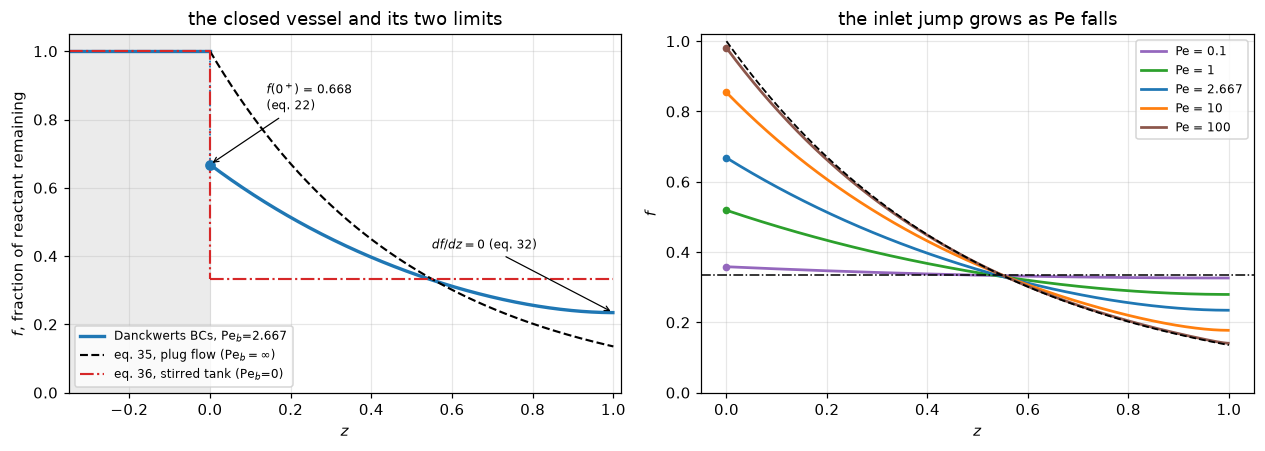

the inlet jump 1 - f(0+), from Wehner & Wilhelm eq. (22):
  Pe =    0.1   f(0+) = 0.3583   jump = 0.6417
  Pe =      1   f(0+) = 0.5189   jump = 0.4811
  Pe =  2.667   f(0+) = 0.6681   jump = 0.3319
  Pe =     10   f(0+) = 0.8541   jump = 0.1459
  Pe =    100   f(0+) = 0.9808   jump = 0.0192


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))

ax = axes[0]
zc, cc, _ = solve_closed(PE_B, R_REF, n=400)
ax.plot([-0.35, 0.0], [1.0, 1.0], color="tab:blue", lw=2.2)
ax.plot(zc, cc, color="tab:blue", lw=2.2, label=f"Danckwerts BCs, Pe$_b$={PE_B}")
ax.plot([0.0, 0.0], [1.0, f0_W22(PE_B, R_REF)], color="tab:blue", lw=1.2, ls=":")
ax.plot(zz, np.exp(-R_REF * zz), color="k", lw=1.4, ls="--",
        label=r"eq. 35, plug flow (Pe$_b=\infty$)")
ax.plot(zz, np.full_like(zz, 1 / (1 + R_REF)), color="tab:red", lw=1.4, ls="-.",
        label=r"eq. 36, stirred tank (Pe$_b$=0)")
ax.plot([-0.35, 0.0, 0.0], [1.0, 1.0, 1 / (1 + R_REF)], color="tab:red", lw=1.4, ls="-.")
ax.plot(0.0, f0_W22(PE_B, R_REF), "o", color="tab:blue", ms=6)
ax.annotate(f"$f(0^+)$ = {f0_W22(PE_B, R_REF):.3f}\n(eq. 22)",
            xy=(0.0, f0_W22(PE_B, R_REF)), xytext=(0.14, 0.83), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.annotate(r"$df/dz=0$ (eq. 32)", xy=(1.0, cc[-1]), xytext=(0.55, 0.42),
            fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
ax.axvspan(-0.35, 0.0, color="0.92")
ax.set(xlabel="$z$", ylabel="$f$, fraction of reactant remaining",
       xlim=(-0.35, 1.02), ylim=(0, 1.05), title="the closed vessel and its two limits")
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
for Pe, col in [(0.1, "tab:purple"), (1.0, "tab:green"), (PE_B, "tab:blue"),
                (10.0, "tab:orange"), (100.0, "tab:brown")]:
    zc, cc, _ = solve_closed(Pe, R_REF, n=400)
    ax.plot(zc, cc, color=col, lw=1.8, label=f"Pe = {Pe:g}")
    ax.plot(0.0, f0_W22(Pe, R_REF), "o", color=col, ms=4)
ax.plot(zz, np.exp(-R_REF * zz), "k--", lw=1.2)
ax.axhline(1 / (1 + R_REF), color="k", ls="-.", lw=1.0)
ax.set(xlabel="$z$", ylabel="$f$", ylim=(0, 1.02),
       title="the inlet jump grows as Pe falls")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("the inlet jump 1 - f(0+), from Wehner & Wilhelm eq. (22):")
for Pe in (0.1, 1.0, PE_B, 10.0, 100.0):
    print(f"  Pe = {Pe:6g}   f(0+) = {f0_W22(Pe, R_REF):.4f}   jump = "
          f"{1-f0_W22(Pe, R_REF):.4f}")

## Validation

Five checks, in the order `docs/agent-brief.md` ranks them, each followed by what
it cannot see.

### 1. The closed form, and the observed order

The pymrm solve and Danckwerts' eq. (34) share nothing but the two parameters:
one assembles a finite-volume operator, the other evaluates an exponential
expression transcribed from a page image. Refining the grid must drive them
together at the scheme's order — **first** for bare upwind, **second** with the
van Leer deferred correction.

In [7]:
rows = []
for n in (25, 50, 100, 200, 400, 800, 1600):
    _, c_up, _ = solve_closed(PE_B, R_REF, n=n, limiter=None)
    _, c_tv, _ = solve_closed(PE_B, R_REF, n=n)
    rows.append((n, abs(c_up[-1] / f_ex - 1), abs(c_tv[-1] / f_ex - 1)))

print(f"{'n':>6} {'upwind':>12} {'order':>7} {'van Leer':>12} {'order':>7}")
for i, (n, e_up, e_tv) in enumerate(rows):
    o_up = np.log2(rows[i-1][1] / e_up) if i else np.nan
    o_tv = np.log2(rows[i-1][2] / e_tv) if i else np.nan
    print(f"{n:6d} {e_up:12.3e} {o_up:7.2f} {e_tv:12.3e} {o_tv:7.2f}")

ORDER_UP = float(np.log2(rows[-2][1] / rows[-1][1]))
ORDER_TV = float(np.log2(rows[-2][2] / rows[-1][2]))
ERR_TV = float(rows[-1][2])
print(f"\nobserved order: upwind {ORDER_UP:.2f}, van Leer {ORDER_TV:.2f}")

# the upwind error is not just "first order" - it has a known mechanism
print("\nUpwind adds a numerical diffusivity u*dz/2, which is the same thing as")
print("solving a smaller Peclet number.  Comparing against eq. 34 evaluated at")
print("Pe_eff = 1/(1/Pe + 1/(2n)) should therefore leave only a SECOND-order residual:")
prev = None
for n in (50, 100, 200, 400, 800, 1600):
    _, c_up, _ = solve_closed(PE_B, R_REF, n=n, limiter=None)
    Pe_eff = 1.0 / (1.0 / PE_B + 1.0 / (2 * n))
    e = abs(c_up[-1] / f_exit_D34(Pe_eff, R_REF) - 1)
    print(f"   n={n:5d}  residual {e:9.3e}" + (f"   order {np.log2(prev/e):5.2f}" if prev else ""))
    prev = e
PE_EFF_200 = 1.0 / (1.0 / 200.0 + 1.0 / (2 * 200))
print(f"\nSo a bare-upwind study of inlet conditions at Pe = 200 on a 200-cell grid")
print(f"is really running at Pe_eff = {PE_EFF_200:.0f}, and would be measuring its own")
print("truncation error as though it were a boundary-condition effect.")

     n       upwind   order     van Leer   order
    25    1.238e-02     nan    9.529e-04     nan
    50    5.916e-03    1.06    2.350e-04    2.02
   100    2.886e-03    1.04    5.804e-05    2.02
   200    1.424e-03    1.02    1.437e-05    2.01
   400    7.072e-04    1.01    3.570e-06    2.01
   800    3.524e-04    1.00    8.889e-07    2.01
  1600    1.759e-04    1.00    2.217e-07    2.00

observed order: upwind 1.00, van Leer 2.00

Upwind adds a numerical diffusivity u*dz/2, which is the same thing as
solving a smaller Peclet number.  Comparing against eq. 34 evaluated at
Pe_eff = 1/(1/Pe + 1/(2n)) should therefore leave only a SECOND-order residual:
   n=   50  residual 3.696e-04
   n=  100  residual 9.457e-05   order  1.97
   n=  200  residual 2.392e-05   order  1.98
   n=  400  residual 6.016e-06   order  1.99
   n=  800  residual 1.509e-06   order  2.00
   n= 1600  residual 3.777e-07   order  2.00

So a bare-upwind study of inlet conditions at Pe = 200 on a 200-cell grid
is really

**What check 1 cannot see.** It is one number at one operating point, so it
cannot detect a defect that only shows at another $\mathrm{Pe}$ or $R$ — check 2
sweeps eight decades for that reason. It also has weak power against
**under-resolution here specifically**: at $\mathrm{Pe}_b = 2.667$ the profile is
so smooth that 10 cells are already within 0.6 % (see the break table), whereas
at $\mathrm{Pe} = 200$ the same 10 cells are wrong by far more. Grid convergence
is reported as a table, not as a single tolerance, for exactly that reason.

### 2. The two exact limits, and the printed asymptote

Danckwerts' eqs. (35) and (36) are limits the model must hit, not
approximations: $f \to e^{-R}$ as $\mathrm{Pe}\to\infty$ and $f \to 1/(1+R)$ as
$\mathrm{Pe}\to 0$. His eq. (37) claims something sharper — that the approach to
plug flow is $f \approx (1 + R^{2}/\mathrm{Pe})e^{-R}$ — which fixes both the
sign and the size of the first correction, and can be tested for its **order**.

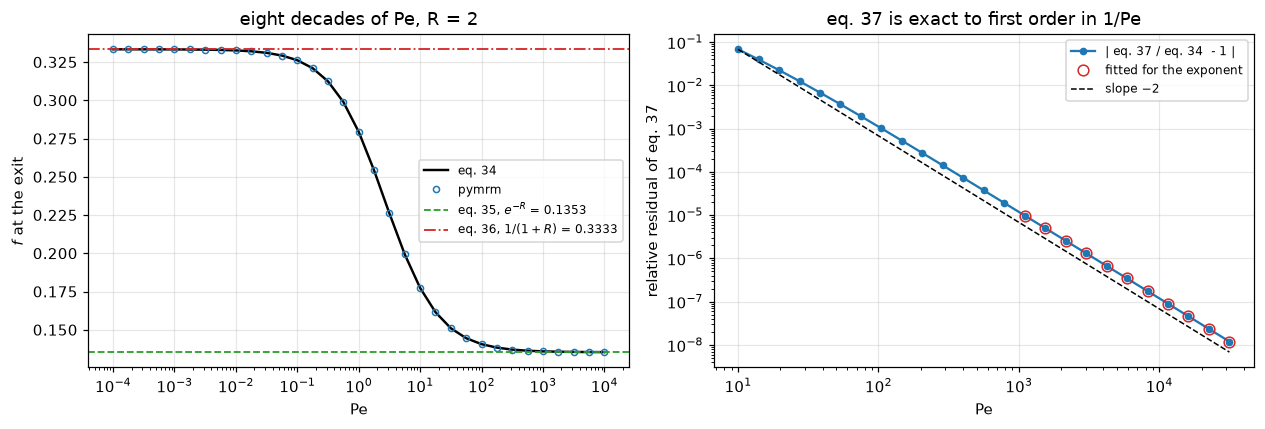

pymrm vs eq. 34 over Pe = 1e-4 .. 1e4 : worst 1.88e-04
eq. 34 -> eq. 35 (plug)  at Pe = 1e8  : 4.55e-08
eq. 34 -> eq. 36 (CSTR)  at Pe = 1e-8 : 2.22e-09
eq. 37 residual decays as Pe^-2.00, fitted over the asymptotic end
  Pe >= 1e3 (11 points); the R^2/Pe term is therefore the exact first
  correction, with the next one down at 1/Pe^2.  Fitting the whole plotted
  range instead returns 1.95, which is not a second exponent but the
  pre-asymptotic bottom end leaking in: at Pe = 10, R^2/Pe = 0.4 is not small.
At Pe = 100 the approximation is 0.112 % high.
His own criterion k^2 D L/u^3 = R^2/Pe < 1 is met from Pe > 4.


In [8]:
pe_sweep = np.logspace(-4, 4, 33)
f_pymrm = np.array([solve_closed(p, R_REF, n=1600)[1][-1] for p in pe_sweep])
f_exact = f_exit_D34(pe_sweep, R_REF)
SWEEP_WORST = float(np.max(np.abs(f_pymrm / f_exact - 1)))

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.0))
ax = axes[0]
ax.semilogx(pe_sweep, f_exact, "k-", lw=1.6, label="eq. 34")
ax.semilogx(pe_sweep, f_pymrm, "o", ms=4, mfc="none", color="tab:blue", label="pymrm")
ax.axhline(np.exp(-R_REF), color="tab:green", ls="--", lw=1.2,
           label=fr"eq. 35, $e^{{-R}}$ = {np.exp(-R_REF):.4f}")
ax.axhline(1 / (1 + R_REF), color="tab:red", ls="-.", lw=1.2,
           label=fr"eq. 36, $1/(1+R)$ = {1/(1+R_REF):.4f}")
ax.set(xlabel="Pe", ylabel="$f$ at the exit",
       title=f"eight decades of Pe, R = {R_REF:g}")
ax.legend(fontsize=8)

ax = axes[1]
pe_hi = np.logspace(1, 4.5, 25)
res = np.abs((1 + R_REF ** 2 / pe_hi) * np.exp(-R_REF) / f_exit_D34(pe_hi, R_REF) - 1)
# the exponent is ASYMPTOTIC in 1/Pe, so it is fitted only where 1/Pe is small.
# At the bottom of the range R^2/Pe = 0.4, and a fit that includes it reads low.
FIT37 = pe_hi >= 1e3
ax.loglog(pe_hi, res, "o-", ms=4, color="tab:blue", label="| eq. 37 / eq. 34  - 1 |")
ax.loglog(pe_hi[FIT37], res[FIT37], "o", ms=7, mfc="none", color="tab:red",
          label="fitted for the exponent")
ax.loglog(pe_hi, res[0] * (pe_hi / pe_hi[0]) ** -2.0, "k--", lw=1.0,
          label=r"slope $-2$")
ax.set(xlabel="Pe", ylabel="relative residual of eq. 37",
       title="eq. 37 is exact to first order in 1/Pe")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

EQ37_ORDER = float(-np.polyfit(np.log(pe_hi[FIT37]), np.log(res[FIT37]), 1)[0])
EQ37_ORDER_ALL = float(-np.polyfit(np.log(pe_hi), np.log(res), 1)[0])
LIM_PLUG = abs(f_exit_D34(1e8, R_REF) / np.exp(-R_REF) - 1)
LIM_CSTR = abs(f_exit_D34(1e-8, R_REF) / (1 / (1 + R_REF)) - 1)
print(f"pymrm vs eq. 34 over Pe = 1e-4 .. 1e4 : worst {SWEEP_WORST:.2e}")
print(f"eq. 34 -> eq. 35 (plug)  at Pe = 1e8  : {LIM_PLUG:.2e}")
print(f"eq. 34 -> eq. 36 (CSTR)  at Pe = 1e-8 : {LIM_CSTR:.2e}")
print(f"eq. 37 residual decays as Pe^-{EQ37_ORDER:.2f}, fitted over the asymptotic end")
print(f"  Pe >= 1e3 ({FIT37.sum()} points); the R^2/Pe term is therefore the exact first")
print(f"  correction, with the next one down at 1/Pe^2.  Fitting the whole plotted")
print(f"  range instead returns {EQ37_ORDER_ALL:.2f}, which is not a second exponent but the")
print(f"  pre-asymptotic bottom end leaking in: at Pe = 10, R^2/Pe = {R_REF**2/10:.1f} is not small.")
print(f"At Pe = 100 the approximation is "
      f"{100*abs((1+R_REF**2/100)*np.exp(-R_REF)/f_exit_D34(100.,R_REF)-1):.3f} % high.")
print(f"His own criterion k^2 D L/u^3 = R^2/Pe < 1 is met from Pe > {R_REF**2:.0f}.")

**What check 2 cannot see.** The two limits are limits of the *closed form*, so
they test the transcription and the pymrm solve against it, not the modelling
choice; and both limits are reached by *any* reasonable pair of boundary
conditions at $\mathrm{Pe}\to\infty$ (convection swamps everything). Only the
$\mathrm{Pe}\to 0$ limit discriminates between inlet conditions — which is
precisely Wehner & Wilhelm's objection to Hulburt, and check 5 turns it into a
number.

### 3. Wehner & Wilhelm's three sections — a route that never writes a Danckwerts condition

This is the check with the most power, because it obtains the same profile from
a **different problem statement** — though, to be precise about what that buys,
not from different code: it shares `construct_grad`, `construct_div`,
`construct_convflux_upwind`, the van Leer deferred correction and the solver with
`solve_closed`, and the check below shows its condition at $z = 1$ is
*discretely identical* to the closed vessel's. What it genuinely establishes is
that Danckwerts' closure is the right reduction of the three-section problem —
it separates his solution from Hulburt's by 50 % at the reference point — and
that the reaction section is invariant to both end sections.

The domain runs from far upstream to
far downstream in **one** grid, with a piecewise diffusivity
($1/\mathrm{Pe}_a$, $1/\mathrm{Pe}_b$, $1/\mathrm{Pe}_c$) and reaction only
inside $0<z<1$. The only boundary conditions imposed are Wehner & Wilhelm's own
eqs. (8) and (15): $f = 1$ far upstream, and $f$ finite far downstream, which for
a section with no reaction is rendered exactly by a zero gradient at the
truncation. **Nothing is imposed at $z=0$ or $z=1$** — the interfaces are
ordinary interior faces where the finite-volume scheme enforces continuity of $f$
and of the total flux, which are their eqs. (11)–(14).

At a jump in $D$ the face diffusivity must be the **harmonic** mean of the two
neighbouring cell values, because that is what keeps the diffusive flux
continuous when the profile has a kink. The arithmetic mean leaves an $O(1)$
flux error at that one face, and the cost is an **order**, not a factor: the
study below refines the bed and reports both convergence rates, because a single
"$N\times$ worse" number is a property of the grid it was measured on.

In [9]:
def geom_faces(length, dz0, ratio=1.06):
    """Faces 0 .. length with cells growing geometrically from dz0 - lets the
    fore and after sections reach 30 decay lengths without a huge cell count."""
    n = int(np.ceil(np.log1p(length * (ratio - 1) / dz0) / np.log(ratio)))
    f = np.concatenate([[0.0], np.cumsum(dz0 * ratio ** np.arange(n))])
    return f * (length / f[-1])


TS_ITERS = []            # deferred-correction iteration counts, checked at the end


def three_section(Pe_a, Pe_b, Pe_c, R, n_b=400, u=1.0, P=30.0, stretch=True,
                  face_average="harmonic", P_after=None):
    """Wehner & Wilhelm's fore | reaction | after problem as ONE pymrm domain.

    `P` is the length of each end section in its own decay lengths; `P_after`
    overrides it for the after section alone, which is how the flat-after check
    below is shown to be structural.
    """
    dz0 = 1.0 / n_b
    P_a = P if P_after is None else P_after
    if stretch:
        z_up = -geom_faces(P / Pe_a, dz0)[::-1]
        z_dn = geom_faces(P_a / Pe_c, dz0) + 1.0
    else:
        z_up = np.linspace(-P / Pe_a, 0.0, int(P / Pe_a / dz0) + 1)
        z_dn = np.linspace(1.0, 1.0 + P_a / Pe_c, int(P_a / Pe_c / dz0) + 1)
    z_f = np.concatenate([z_up[:-1], np.linspace(0.0, 1.0, n_b + 1)[:-1], z_dn])
    n = len(z_f) - 1
    z_c = 0.5 * (z_f[:-1] + z_f[1:])
    shape = (n, 1)

    D_cell = np.where((z_c > 0) & (z_c < 1.0), 1 / Pe_b,
                      np.where(z_c < 0, 1 / Pe_a, 1 / Pe_c))
    # harmonic mean on interior faces keeps the diffusive flux continuous across
    # the two jumps in D; arithmetic averaging does not
    Dl, Dr = D_cell[:-1], D_cell[1:]
    D_f = np.empty(n + 1)
    D_f[1:-1] = (2 * Dl * Dr / (Dl + Dr) if face_average == "harmonic"
                 else 0.5 * (Dl + Dr))
    D_f[0], D_f[-1] = D_cell[0], D_cell[-1]
    k_c = np.where((z_c > 0) & (z_c < 1.0), R, 0.0)

    # W&W eq. (8): f(-inf) = 1        -> a=0, b=1, d=1 at the upstream end
    # W&W eq. (15): f(+inf) is finite -> no growing mode; with no reaction there
    #   this is exactly df/dn = 0 at any truncation  -> a=1, b=0, d=0
    bc = ({"a": 0.0, "b": 1.0, "d": 1.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
    conv, conv_bc = construct_convflux_upwind(shape, z_f, z_c, bc, v=u)
    grad, grad_bc = construct_grad(shape, z_f, z_c, bc)
    div = construct_div(shape, z_f, nu=0)                       # nu=0: Cartesian
    Dm = construct_coefficient_matrix(D_f.reshape(-1, 1), shape=shape, axis=0)
    Km = construct_coefficient_matrix(k_c.reshape(-1, 1), shape=shape)

    A = (div @ (conv - Dm @ grad) + Km).tocsc()
    b0 = np.asarray((div @ (conv_bc - Dm @ grad_bc)).todense()).ravel()
    lu = splu(A)
    c = lu.solve(-b0)
    # Tolerance 1e-11, not the 1e-14 used in the closed vessel: the geometrically
    # stretched grid reaches 3000 units of length in ~700 cells, and the sparse
    # solve on it has a roundoff floor around 1e-13..1e-11, below which successive
    # deferred-correction iterates just wander.  Asking for 1e-14 here does not
    # give a better answer, it gives a loop that silently exits at `max_it` -
    # which is what the assertion below exists to make impossible.
    done = False
    for it in range(1, 81):
        _, dc_f = interp_cntr_to_stagg_tvd(c.reshape(shape), z_f, z_c, bc, u,
                                           tvd_limiter=vanleer, axis=0)
        c_new = lu.solve(-b0 - np.asarray(div @ (u * dc_f.reshape(-1, 1))).ravel())
        done = np.max(np.abs(c_new - c)) < 1e-11
        c = c_new
        if done:
            break
    assert done, "three-section deferred correction did not converge in 80 iterations"
    TS_ITERS.append(it)
    _, dc_f = interp_cntr_to_stagg_tvd(c.reshape(shape), z_f, z_c, bc, u,
                                       tvd_limiter=vanleer, axis=0)
    flux = np.asarray(conv @ c.reshape(-1, 1) + conv_bc
                      - Dm @ (grad @ c.reshape(-1, 1) + grad_bc)
                      + u * dc_f.reshape(-1, 1)).ravel()
    return z_c, c, z_f, flux


print("Wehner & Wilhelm's claim: the reaction section does not depend on either")
print("end section.  Sweeping Pe_a over five decades and Pe_c over four:\n")
print(f"{'Pe_a':>9} {'Pe_c':>9} {'max|f - eq.33| in bed':>23} {'f(exit) vs eq.21':>18}")
ts_dev, ts_exit = [], []
for Pe_a, Pe_c in [(0.01, 1.0), (0.1, 1.0), (1.0, 1.0), (10.0, 1.0), (1000.0, 1.0),
                   (1.0, 0.01), (1.0, 100.0)]:
    zc, cc, zf, fl = three_section(Pe_a, PE_B, Pe_c, R_REF)
    m = (zc > 0) & (zc < 1.0)
    dev = float(np.max(np.abs(cc[m] - c_prof_D33(zc[m], PE_B, R_REF))))
    ex = float(abs(cc[-1] / f_exit_W21(PE_B, R_REF) - 1))
    ts_dev.append(dev); ts_exit.append(ex)
    print(f"{Pe_a:9.2f} {Pe_c:9.2f} {dev:23.3e} {ex:18.3e}")

TS_DEV = float(np.max(ts_dev))
TS_SPREAD = float(np.ptp(ts_exit))
print(f"\nworst deviation from the closed vessel, over all seven runs: {TS_DEV:.2e}")
print(f"spread of f(exit) across them:                              {TS_SPREAD:.2e}")
print("The reaction section is blind to both end sections, as they claim, and the")
print("Danckwerts conditions are what a solve that never mentions them produces.")

Wehner & Wilhelm's claim: the reaction section does not depend on either
end section.  Sweeping Pe_a over five decades and Pe_c over four:

     Pe_a      Pe_c   max|f - eq.33| in bed   f(exit) vs eq.21
     0.01      1.00               1.921e-06          8.114e-07
     0.10      1.00               1.824e-06          8.109e-07
     1.00      1.00               8.502e-07          8.061e-07
    10.00      1.00               3.493e-06          7.842e-07
  1000.00      1.00               8.020e-06          7.609e-07
     1.00      0.01               8.502e-07          8.061e-07
     1.00    100.00               8.502e-07          8.061e-07

worst deviation from the closed vessel, over all seven runs: 8.02e-06
spread of f(exit) across them:                              5.06e-08
The reaction section is blind to both end sections, as they claim, and the
Danckwerts conditions are what a solve that never mentions them produces.


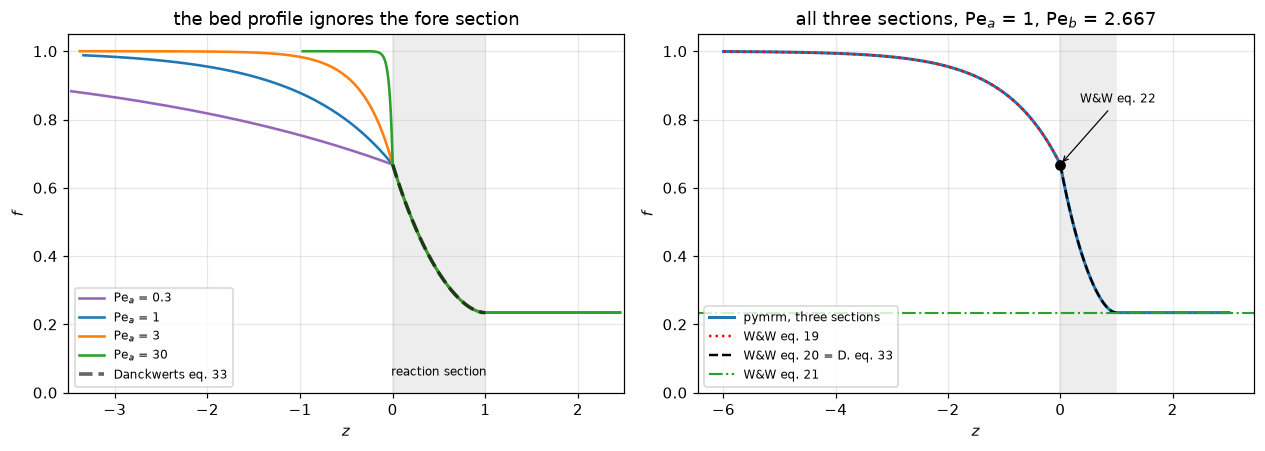

fore section   vs W&W eq. 19 : max |deviation| 9.03e-07
reaction sect. vs W&W eq. 20 : max |deviation| 8.49e-07
exit value     vs W&W eq. 21 : relative        8.07e-07
  -- those three are measurements: each has a closed form it could disagree
     with, and the arithmetic-mean run below shows the first one moving.

after section  flat?         : peak-to-peak    2.64e-11
fore-section flux, claimed constant at 1.0     : max |F-1| 6.97e-10
  -- BOTH of those are STRUCTURAL, and neither can fail.  With no source
     upstream the discrete divergence is zero cell by cell, so the fore
     flux is constant by construction; only its VALUE of 1.0 carries
     information, as a check that the upstream domain is long enough.
     Downstream the same flux balance with no reaction and constant D
     forces c_i = c_{i+1} exactly, for ANY Pe_c and ANY truncation length,
     so the peak-to-peak above is roundoff and nothing else - it tracks the
     cell count, not the physics.  Measured, against 

In [10]:
# the full three-section profile, on uniform grids, against eqs. 19-22
zc, cc, zf, fl = three_section(PE_A, PE_B, 1.0, R_REF, stretch=False, P=20.0)
m_f, m_b, m_a = zc < 0, (zc > 0) & (zc < 1.0), zc > 1.0

dev_bed = float(np.max(np.abs(cc[m_b] - c_prof_D33(zc[m_b], PE_B, R_REF))))
eq19 = 1.0 - (1.0 - f0_W22(PE_B, R_REF)) * np.exp(PE_A * zc[m_f])
dev_fore = float(np.max(np.abs(cc[m_f] - eq19)))
flat_after = float(np.ptp(cc[m_a]))
dev_exit = float(abs(cc[-1] / f_exit_W21(PE_B, R_REF) - 1))
FORE_FLUX = float(np.max(np.abs(fl[zf < 0] - 1.0)))

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.2))
ax = axes[0]
for Pe_a, col in [(0.3, "tab:purple"), (1.0, "tab:blue"), (3.0, "tab:orange"),
                  (30.0, "tab:green")]:
    z2, c2, _, _ = three_section(Pe_a, PE_B, 1.0, R_REF)
    k = (z2 > -3.5) & (z2 < 2.5)
    ax.plot(z2[k], c2[k], color=col, lw=1.7, label=f"Pe$_a$ = {Pe_a:g}")
ax.plot(zz, c_prof_D33(zz, PE_B, R_REF), "k--", lw=2.4, alpha=0.6,
        label="Danckwerts eq. 33")
ax.axvspan(0, 1, color="0.93")
ax.text(0.5, 0.05, "reaction section", ha="center", fontsize=8)
ax.set(xlabel="$z$", ylabel="$f$", xlim=(-3.5, 2.5), ylim=(0, 1.05),
       title="the bed profile ignores the fore section")
ax.legend(fontsize=8, loc="lower left")

ax = axes[1]
k = (zc > -6) & (zc < 3)
ax.plot(zc[k], cc[k], color="tab:blue", lw=2.0, label="pymrm, three sections")
ax.plot(zc[m_f][zc[m_f] > -6], eq19[zc[m_f] > -6], "r:", lw=1.6, label="W&W eq. 19")
ax.plot(zz, c_prof_D33(zz, PE_B, R_REF), "k--", lw=1.6, label="W&W eq. 20 = D. eq. 33")
ax.axhline(f_exit_W21(PE_B, R_REF), color="tab:green", ls="-.", lw=1.4,
           label="W&W eq. 21")
ax.plot(0.0, f0_W22(PE_B, R_REF), "o", color="k", ms=6)
ax.annotate("W&W eq. 22", xy=(0.0, f0_W22(PE_B, R_REF)), xytext=(0.35, 0.85),
            fontsize=8, arrowprops=dict(arrowstyle="->", lw=0.8))
ax.axvspan(0, 1, color="0.93")
ax.set(xlabel="$z$", ylabel="$f$", ylim=(0, 1.05),
       title=fr"all three sections, Pe$_a$ = {PE_A:g}, Pe$_b$ = {PE_B:g}")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

print(f"fore section   vs W&W eq. 19 : max |deviation| {dev_fore:.2e}")
print(f"reaction sect. vs W&W eq. 20 : max |deviation| {dev_bed:.2e}")
print(f"exit value     vs W&W eq. 21 : relative        {dev_exit:.2e}")
print("  -- those three are measurements: each has a closed form it could disagree")
print("     with, and the arithmetic-mean run below shows the first one moving.")
print()
print(f"after section  flat?         : peak-to-peak    {flat_after:.2e}")
print(f"fore-section flux, claimed constant at 1.0     : max |F-1| {FORE_FLUX:.2e}")
print("  -- BOTH of those are STRUCTURAL, and neither can fail.  With no source")
print("     upstream the discrete divergence is zero cell by cell, so the fore")
print("     flux is constant by construction; only its VALUE of 1.0 carries")
print("     information, as a check that the upstream domain is long enough.")
print("     Downstream the same flux balance with no reaction and constant D")
print("     forces c_i = c_{i+1} exactly, for ANY Pe_c and ANY truncation length,")
print("     so the peak-to-peak above is roundoff and nothing else - it tracks the")
print("     cell count, not the physics.  Measured, against the 20-decay-length,")
print("     8000-cell after section that produced the number above:")

In [11]:
# is "the after section is flat" a measurement or an identity?  Truncate it.
# Everything else - Pe_a, Pe_b, Pe_c, the bed grid, the fore section - is held
# at the values that produced the 20-decay-length numbers printed above.
for P_after in (2.0, 0.2):
    z3, c3, _, _ = three_section(PE_A, PE_B, 1.0, R_REF, stretch=False, P=20.0,
                                 P_after=P_after)
    ma3, mb3 = z3 > 1.0, (z3 > 0) & (z3 < 1.0)
    print(f"  after section {P_after:5g} decay lengths ({ma3.sum():5d} cells): "
          f"peak-to-peak {float(np.ptp(c3[ma3])):.2e}, "
          f"bed profile unchanged to {float(np.max(np.abs(c3[mb3] - cc[m_b]))):.1e}")
print("An after section 100x too short reads as flat just as convincingly, and the")
print("bed does not notice, so flatness is evidence about the DISCRETISATION, not")
print("about Pe_c or the truncation length.  What it does license is the argument")
print("in the next cell: flat implies zero diffusive flux at z = 1.")

  after section     2 decay lengths (  800 cells): peak-to-peak 3.78e-12, bed profile unchanged to 4.1e-13
  after section   0.2 decay lengths (   80 cells): peak-to-peak 5.05e-14, bed profile unchanged to 1.8e-12
An after section 100x too short reads as flat just as convincingly, and the
bed does not notice, so flatness is evidence about the DISCRETISATION, not
about Pe_c or the truncation length.  What it does license is the argument
in the next cell: flat implies zero diffusive flux at z = 1.


**What the arithmetic face average would have cost, and why no single factor
should be quoted.** Re-running the same problem with $D$ averaged arithmetically
at the two jumps, refining only the bed:

In [12]:
N_BED = (100, 200, 400, 800)
face_err = {"arithmetic": [], "harmonic": []}
for n_b in N_BED:
    for fa in face_err:
        z4, c4, _, _ = three_section(PE_A, PE_B, 1.0, R_REF, n_b=n_b,
                                     stretch=False, P=20.0, face_average=fa)
        m4 = z4 < 0
        eq19_4 = 1.0 - (1.0 - f0_W22(PE_B, R_REF)) * np.exp(PE_A * z4[m4])
        face_err[fa].append(float(np.max(np.abs(c4[m4] - eq19_4))))

ratio = [a / h for a, h in zip(face_err["arithmetic"], face_err["harmonic"])]
print(f"{'n_b':>6} {'arithmetic':>12} {'order':>7} {'harmonic':>12} {'order':>7} {'ratio':>7}")
for i, n_b in enumerate(N_BED):
    o_a = np.log2(face_err["arithmetic"][i-1] / face_err["arithmetic"][i]) if i else np.nan
    o_h = np.log2(face_err["harmonic"][i-1] / face_err["harmonic"][i]) if i else np.nan
    mark = "   <- this page's grid" if n_b == 400 else ""
    print(f"{n_b:6d} {face_err['arithmetic'][i]:12.3e} {o_a:7.2f} "
          f"{face_err['harmonic'][i]:12.3e} {o_h:7.2f} {ratio[i]:7.0f}{mark}")

ORDER_ARITH = float(np.log2(face_err["arithmetic"][-2] / face_err["arithmetic"][-1]))
ORDER_HARM = float(np.log2(face_err["harmonic"][-2] / face_err["harmonic"][-1]))
ARITH_FORE = face_err["arithmetic"][N_BED.index(400)]
ARITH_RATIO_400 = ratio[N_BED.index(400)]
print(f"\nThe arithmetic mean converges at order {ORDER_ARITH:.2f} at the jump, the harmonic")
print(f"at order {ORDER_HARM:.2f}, so the ratio is not a constant - it grows in proportion")
print(f"to n, without bound.  The {ARITH_RATIO_400:.0f}x on this page's n_b = 400 grid is "
      f"{ratio[0]:.0f}x on a")
print(f"{N_BED[0]}-cell bed and {ratio[-1]:.0f}x on an {N_BED[-1]}-cell one.  Quote the ORDER: a lone factor")
print("is a property of the grid it was measured on, and on a coarse grid it looks")
print("small enough to dismiss the rule.")
print()
print("And it fails SILENTLY.  Same two runs at n_b = 400, looking at what a reader")
print("would actually see:")
out = {}
for fa in ("harmonic", "arithmetic"):
    z5, c5, _, _ = three_section(PE_A, PE_B, 1.0, R_REF, stretch=False, P=20.0,
                                 face_average=fa)
    mb5 = (z5 > 0) & (z5 < 1.0)
    out[fa] = (float(c5[mb5][0]), float(c5[-1]),
               float(np.max(np.abs(c5[mb5] - c_prof_D33(z5[mb5], PE_B, R_REF)))))
    print(f"  {fa:>10}: f in the first bed cell {out[fa][0]:.6f}, "
          f"f(exit) {out[fa][1]:.8f}, bed vs eq. 33 {out[fa][2]:.1e}")
print(f"  the exit value moves by {abs(out['arithmetic'][1]-out['harmonic'][1]):.0e} and the profile stays smooth and")
print("  plausible: nothing downstream of the jump reports the error.  The damage")
print("  is real but LOCAL - it is the fore section, not the answer, that is wrong.")

   n_b   arithmetic   order     harmonic   order   ratio
   100    1.241e-03     nan    1.471e-05     nan      84
   200    6.248e-04    0.99    3.632e-06    2.02     172
   400    3.134e-04    1.00    9.026e-07    2.01     347   <- this page's grid
   800    1.569e-04    1.00    2.254e-07    2.00     696

The arithmetic mean converges at order 1.00 at the jump, the harmonic
at order 2.00, so the ratio is not a constant - it grows in proportion
to n, without bound.  The 347x on this page's n_b = 400 grid is 84x on a
100-cell bed and 696x on an 800-cell one.  Quote the ORDER: a lone factor
is a property of the grid it was measured on, and on a coarse grid it looks
small enough to dismiss the rule.

And it fails SILENTLY.  Same two runs at n_b = 400, looking at what a reader
would actually see:
    harmonic: f in the first bed cell 0.667012, f(exit) 0.23442834, bed vs eq. 33 8.5e-07
  arithmetic: f in the first bed cell 0.667011, f(exit) 0.23442834, bed vs eq. 33 1.6e-06
  the exit value

**Danckwerts' intuition, recovered.** Nothing in the three-section solve imposes
$\mathrm{d}f/\mathrm{d}z = 0$ at $z=1$. It comes out, because the after section
has no reaction and must stay bounded, so it is flat, so continuity of flux
drags the zero gradient back to the bed exit — Wehner & Wilhelm's *"the boundary
condition at $z = +\infty$ is drawn to the end of the reaction bed."*

Two things have to be separated here, and the cell below separates them.

- **The chain itself is exact in the discrete system.** Flat after section means
  the last bed cell and the first after-section cell hold the same value, so the
  diffusive flux across $z=1$ is identically zero. That is measured below and it
  is at machine precision — nothing about it converges, and the effective
  discrete condition at $z=1$ is the *same* condition as `bc_out = {a:1, b:0,
  d:0}` in the closed vessel.
- **Reading a gradient back off cell-centre values is a lossy estimator.** The
  3-point quadratic fit used below returns a small non-zero number even when it
  is fed the *exact* eq. 33, whose gradient at $z=1$ is exactly zero. So the
  same fit is applied to the closed form on the same cell centres, and both
  columns are printed. Most of what the estimator returns is its own truncation
  error; the part that belongs to the solution is the difference.

In [13]:
print("gradient at z = 1 recovered from the three-section solve (never imposed there),")
print("beside the SAME 3-point fit applied to the exact eq. 33, whose true gradient")
print("at z = 1 is zero:\n")
print(f"{'n_b':>6} {'fit on the solve':>18} {'fit on exact eq.33':>20} "
      f"{'difference':>13} {'|last bed - after|':>20}")
g_solve, g_fitbias, g_resid, gaps = [], [], [], []
for n_b in (100, 200, 400, 800):
    zc2, cc2, _, _ = three_section(PE_A, PE_B, 1.0, R_REF, n_b=n_b)
    m = (zc2 > 0) & (zc2 < 1.0)
    zb, cb = zc2[m][-3:], cc2[m][-3:]
    g1 = float(np.polyval(np.polyder(np.polyfit(zb, cb, 2)), 1.0))
    ge = float(np.polyval(np.polyder(
        np.polyfit(zb, c_prof_D33(zb, PE_B, R_REF), 2)), 1.0))
    gap = float(abs(cc2[m][-1] - cc2[zc2 > 1.0][0]))
    g_solve.append(abs(g1)); g_fitbias.append(abs(ge)); g_resid.append(abs(g1 - ge))
    gaps.append(gap)
    print(f"{n_b:6d} {g1:18.4e} {ge:20.4e} {g1-ge:13.3e} {gap:20.1e}")

GRAD_EXIT = g_solve[-1]
GRAD_FIT_BIAS = g_fitbias[-1]
GRAD_RESID = g_resid[-1]
ORDER_GRAD = float(np.log2(g_resid[-2] / g_resid[-1]))
print(f"\n{100*GRAD_FIT_BIAS/GRAD_EXIT:.0f} % of the recovered gradient is the estimator, not the solution:")
print("the same fit on the exact closed form returns nearly the same number.  What")
print(f"is left after subtracting it falls at order {ORDER_GRAD:.2f} (as does the estimator's own")
print("bias), so the conclusion holds - but the printed magnitude is a")
print("post-processing artefact and should not be read as a physical gradient.")
print()
GRAD_GAP = float(max(gaps))
print(f"The last column is the real content: over every n_b above, the last bed cell")
print(f"and the first after-section cell agree to {GRAD_GAP:.1e}, so the chain")
print("'after section flat => zero diffusive flux at z = 1' is EXACT in the discrete")
print("system, not second-order.  The effective condition at z = 1 in this solve is")
print("discretely identical to bc_out = {a: 1, b: 0, d: 0} in the closed vessel.")
print()
print("Honest limit of this check: imposing boundedness at the far downstream")
print("truncation is itself a zero-gradient condition, applied one section away.")
print("What is demonstrated is the chain from f(+inf) finite to df/dz(1)=0, which")
print("is Wehner & Wilhelm's argument - not an independent proof of its premise.")

gradient at z = 1 recovered from the three-section solve (never imposed there),
beside the SAME 3-point fit applied to the exact eq. 33, whose true gradient
at z = 1 is zero:

   n_b   fit on the solve   fit on exact eq.33    difference   |last bed - after|
   100        -3.6404e-04          -3.0440e-04    -5.965e-05              2.8e-17
   200        -9.2742e-05          -7.7977e-05    -1.477e-05              5.6e-17
   400        -2.3403e-05          -1.9733e-05    -3.670e-06              1.7e-16
   800        -5.8782e-06          -4.9634e-06    -9.148e-07              5.0e-16

84 % of the recovered gradient is the estimator, not the solution:
the same fit on the exact closed form returns nearly the same number.  What
is left after subtracting it falls at order 2.00 (as does the estimator's own
bias), so the conclusion holds - but the printed magnitude is a
post-processing artefact and should not be read as a physical gradient.

The last column is the real content: over every n_b abo

**And the other Danckwerts condition, qualified by the same model.** Wehner &
Wilhelm wrote of the inlet discontinuity that it *"will be shown later to be not
necessarily correct"*. Here is what they meant, measured: in the three-section
problem $f$ is continuous at $z = 0$, and the fall from 1 to $f(0)$ is spread
over the fore section on the scale $1/\mathrm{Pe}_a$. The mesh resolves it, so
what the solve shows at the entrance is a **kink in slope**, not a jump — and it
only becomes Danckwerts' step in the limit $\mathrm{Pe}_a\to\infty$.

In [14]:
print("adjacent-cell difference across z = 0 in the three-section solve, n_b = 200")
print("(the closed-vessel idealisation puts a full "
      f"{1-f0_W22(PE_B, R_REF):.3f} step there):\n")
print(f"{'Pe_a':>10} {'f(0-)':>10} {'f(0+)':>10} {'f(0-) - f(0+)':>16}")
jumps, f0_in = [], []
for Pe_a in (0.3, 1.0, 3.0, 30.0, 1000.0):
    z6, c6, _, _ = three_section(Pe_a, PE_B, 1.0, R_REF, n_b=200)
    i = int(np.searchsorted(z6, 0.0))          # first cell centre inside the bed
    jumps.append(float(c6[i-1] - c6[i])); f0_in.append(float(c6[i]))
    print(f"{Pe_a:10g} {c6[i-1]:10.6f} {c6[i]:10.6f} {jumps[-1]:16.2e}")
INLET_STEP_PE1 = jumps[1]
INLET_STEP_HI = jumps[-1]
print(f"\nAt Pe_a = 1 the entire cell-to-cell change is {INLET_STEP_PE1:.1e}, against a")
print(f"closed-vessel step of {1-f0_W22(PE_B, R_REF):.3f} - a factor "
      f"{(1-f0_W22(PE_B, R_REF))/INLET_STEP_PE1:.0f} apart.  By Pe_a = 1000 it")
print(f"has grown to {INLET_STEP_HI:.1e} and is on its way to the full step.")
print("So Danckwerts' discontinuity is the Pe_a -> infinity idealisation of a")
print("continuous profile, exactly as Wehner & Wilhelm say.  It remains the correct")
print("closure for the bed either way, and the reason is the first bed cell above:")
print(f"f(0+) moves by only {np.ptp(f0_in):.1e} across those five decades of Pe_a, so what")
print("the bed sees is the same whatever the fore section does.")

adjacent-cell difference across z = 0 in the three-section solve, n_b = 200
(the closed-vessel idealisation puts a full 0.332 step there):

      Pe_a      f(0-)      f(0+)    f(0-) - f(0+)


       0.3   0.668344   0.665903         2.44e-03
         1   0.668870   0.665906         2.96e-03
         3   0.670518   0.665912         4.61e-03


        30   0.691585   0.665932         2.57e-02
      1000   0.932289   0.665941         2.66e-01

At Pe_a = 1 the entire cell-to-cell change is 3.0e-03, against a
closed-vessel step of 0.332 - a factor 112 apart.  By Pe_a = 1000 it
has grown to 2.7e-01 and is on its way to the full step.
So Danckwerts' discontinuity is the Pe_a -> infinity idealisation of a
continuous profile, exactly as Wehner & Wilhelm say.  It remains the correct
closure for the bed either way, and the reason is the first bed cell above:
f(0+) moves by only 3.8e-05 across those five decades of Pe_a, so what
the bed sees is the same whatever the fore section does.


### 4. Breaking it on purpose

Every check above is worth exactly what it costs to break. The reference solve is
run again with **one implementation error injected at a time**, and the
deviation from eq. (34) recorded. Anything that does not move the number is a
blind spot, and is named as one.

In [15]:
D_ref = 1.0 / PE_B
defects = [
    ("none (the model as published)", {}),
    ("inlet BC: sign of a flipped (outward normal)", dict(inlet_a=-D_ref)),
    ("inlet BC: naive Dirichlet c(0) = c*", dict(inlet="dirichlet")),
    ("inlet BC: a = D but D taken as 1, not 1/Pe", dict(inlet_a=1.0)),
    ("outlet BC: sign of a flipped", dict(outlet_a=-1.0)),
    ("outlet BC: Dirichlet c(L) = 0", dict(outlet="dirichlet-zero")),
    ("construct_div nu = 1 (cylindrical, wrong)", dict(nu=1)),
    ("reaction term sign flipped", dict(r_sign=-1.0)),
    ("grid coarsened to n = 10", dict(n=10)),
    ("upwind only, no TVD correction", dict(limiter=None)),
]
print(f"{'injected defect':>46} {'f(exit)':>11} {'rel. dev. from eq. 34':>22} {'TVD its':>9}")
break_tab, n_stall, its_ok = {}, 0, None
for label, kw in defects:
    # the ONE place `strict=False` is used: a broken model is allowed to fail to
    # converge, and the last column reports it when it does
    _, cd, it_d = solve_closed(PE_B, R_REF, strict=False, **kw)
    dev = float(abs(cd[-1] / f_ex - 1))
    break_tab[label] = dev
    if it_d < 0:
        n_stall += 1
    if label.startswith("none"):
        its_ok = it_d
    flag = f"{it_d:9d}" if it_d >= 0 else f"{-it_d:6d} !!"
    print(f"{label:>46} {cd[-1]:11.6f} {dev:22.3e} {flag}")
print(f"(!! = ran out of iterations without reaching 1e-14.  The published model")
print(f" needs {its_ok}.  {n_stall} of the injected defects stall instead of converging, so")
print(" for those the solver itself is a second, independent alarm.)")

print(f"\nWhat the closed-form check CATCHES: a mis-signed inlet condition "
      f"({100*break_tab['inlet BC: sign of a flipped (outward normal)']:.0f} %),")
print(f"the naive Dirichlet inlet "
      f"({100*break_tab['inlet BC: naive Dirichlet c(0) = c*']:.0f} %), a wrong "
      "diffusivity in the inlet\ncondition, a Dirichlet outlet, a wrong geometry "
      "index, a sign error on the reaction.")
print("\nWhat it is BLIND to, measured:")
print("  * the sign of `a` at the OUTLET.  Because b = 0 and d = 0 there, the")
print("    condition a*dc/dn = 0 is the same condition for either sign, so the")
print("    outward-normal error is undetectable at that end - by anything.  This")
print("    is stronger than 'the deviation does not move'; see the next cell.")
print("  * under-resolution, at this Pe.  n = 10 costs only "
      f"{100*break_tab['grid coarsened to n = 10']:.2f} %, because")
print("    the profile is smooth at Pe = 2.667.  The same 10 cells at Pe = 200:")
_, c10, _ = solve_closed(200.0, R_REF, n=10)
_, c10b, _ = solve_closed(200.0, R_REF, n=10, limiter=None)
print(f"    van Leer {100*abs(c10[-1]/f_exit_D34(200.,R_REF)-1):6.1f} %, "
      f"upwind {100*abs(c10b[-1]/f_exit_D34(200.,R_REF)-1):6.1f} %  -- so the check")
print("    resolves grid error only where the grid is actually strained.")

                               injected defect     f(exit)  rel. dev. from eq. 34   TVD its
                 none (the model as published)    0.234428              8.889e-07         5
  inlet BC: sign of a flipped (outward normal)    0.697213              1.974e+00     80 !!
           inlet BC: naive Dirichlet c(0) = c*    0.350879              4.967e-01         5
    inlet BC: a = D but D taken as 1, not 1/Pe    0.150928              3.562e-01     80 !!
                  outlet BC: sign of a flipped    0.234428              8.889e-07         5
                 outlet BC: Dirichlet c(L) = 0    0.000584              9.975e-01         5
     construct_div nu = 1 (cylindrical, wrong)   -0.000000              1.000e+00         1
                    reaction term sign flipped   -5.875546              2.606e+01     80 !!
                      grid coarsened to n = 10    0.235837              6.008e-03        12
                upwind only, no TVD correction    0.234511              3.524e-0

**How blind is the outlet, exactly?** "The deviation does not move" would still
leave room for a small effect hidden below the discretisation error. It is
sharper than that: with $b = 0$ and $d = 0$ the sign — indeed the whole value —
of $a$ cancels out of the assembled system, so the matrix and right-hand side
are **bit-identical**. Nothing can detect it, because there is nothing there to
detect. The because-clause is load-bearing, though, and the last row shows it:
make $d$ non-zero and the sign matters again.

In [16]:
A0, rhs0 = solve_closed(PE_B, R_REF, return_system=True)
print(f"{'outlet a':>12} {'max |dA| vs a = 1':>20} {'max |db|':>12}")
for a_out in (1.0, -1.0, 1e7):
    A1, rhs1 = solve_closed(PE_B, R_REF, outlet_a=a_out, return_system=True)
    dA = float(abs(A1 - A0).max()) if (A1 - A0).nnz else 0.0
    print(f"{a_out:12g} {dA:20.2e} {float(np.max(np.abs(rhs1 - rhs0))):12.2e}")
Ai, rhsi = solve_closed(PE_B, R_REF, inlet_a=-1.0 / PE_B, return_system=True)
print(f"{'inlet -D/u':>12} {float(abs(Ai - A0).max()):20.2e} "
      f"{float(np.max(np.abs(rhsi - rhs0))):12.2e}   <- for contrast")
print("\nSo the outlet sign is not weakly detectable, it is ABSENT from the problem.")
print("That depends entirely on d = 0 there.  With a non-zero prescribed flux the")
print("same sign error is a real error:")
for a_out in (1.0, -1.0):
    _, cdd, _ = solve_closed(PE_B, R_REF, outlet_a=a_out, outlet_d=0.05,
                             strict=False)
    print(f"   outlet a = {a_out:+.0f}, d = 0.05  ->  f(exit) = {cdd[-1]:.5f}")
print("Which is the general rule: a homogeneous Neumann condition hides the")
print("outward-normal convention; anything else exposes it.")

    outlet a    max |dA| vs a = 1     max |db|
           1             0.00e+00     0.00e+00
          -1             0.00e+00     0.00e+00
       1e+07             0.00e+00     0.00e+00
  inlet -D/u             1.80e+03     1.60e+03   <- for contrast

So the outlet sign is not weakly detectable, it is ABSENT from the problem.
That depends entirely on d = 0 there.  With a non-zero prescribed flux the
same sign error is a real error:
   outlet a = +1, d = 0.05  ->  f(exit) = 0.24692
   outlet a = -1, d = 0.05  ->  f(exit) = 0.22193
Which is the general rule: a homogeneous Neumann condition hides the
outward-normal convention; anything else exposes it.


### 5. The wrong inlet condition, measured

Replacing the flux balance by $c(0) = c^{*}$ is the mistake this page exists to
prevent. Wehner & Wilhelm identify the result as Hulburt's solution and give it
in closed form — *"arrived at by normalization through division of the
DANCKWERTS solution by $f(0)$"* — so there is a printed prediction for the error:

$$
\frac{f_{\text{Dirichlet}}}{f_{\text{Danckwerts}}} = \frac{1}{f(0)},
\qquad f(0)\ \text{from their eq. (22)} .
$$

The pymrm solve with a Dirichlet inlet knows nothing about that formula, so the
comparison can fail.

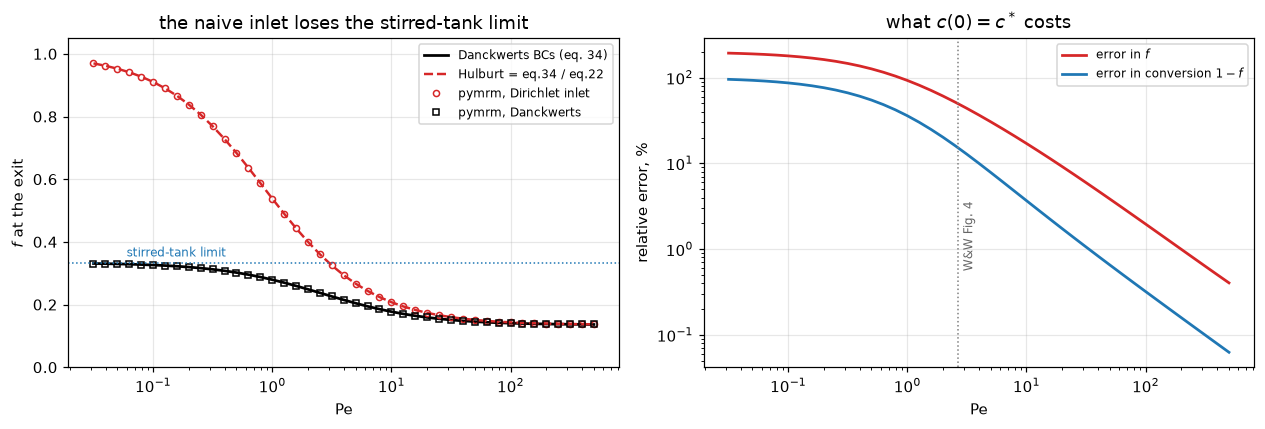

pymrm Dirichlet-inlet solve vs the Hulburt closed form: worst 7.11e-05 over Pe = 0.0316 to 501

       Pe    f true   f naive   err in f   X true  X naive   err in X
    0.100    0.3262    0.9104     179.1 %   0.6738   0.0896     -86.7 %
    0.500    0.3021    0.6842     126.5 %   0.6979   0.3158     -54.7 %
    1.000    0.2794    0.5384      92.7 %   0.7206   0.4616     -35.9 %
    2.667    0.2344    0.3509      49.7 %   0.7656   0.6491     -15.2 %
   10.000    0.1773    0.2076      17.1 %   0.8227   0.7924      -3.7 %
   50.000    0.1456    0.1512       3.9 %   0.8544   0.8488      -0.7 %
  200.000    0.1380    0.1394       1.0 %   0.8620   0.8606      -0.2 %

As Pe -> 0 the naive inlet gives f -> 1.0000,
i.e. NO conversion, where the stirred-tank answer is 1/(1+R) = 0.3333.
That is Wehner & Wilhelm's objection, as a number.


In [17]:
pes = np.logspace(-1.5, 2.7, 43)
f_dan = np.array([solve_closed(p, R_REF, n=1200)[1][-1] for p in pes])
f_dir = np.array([solve_closed(p, R_REF, n=1200, inlet="dirichlet")[1][-1] for p in pes])
f_hul = f_exit_D34(pes, R_REF) / f0_W22(pes, R_REF)
HULBURT_DEV = float(np.max(np.abs(f_dir / f_hul - 1)))

err_f = (f_dir - f_exit_D34(pes, R_REF)) / f_exit_D34(pes, R_REF)
X_dan, X_dir = 1 - f_exit_D34(pes, R_REF), 1 - f_hul
err_X = (X_dir - X_dan) / X_dan

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.0))
ax = axes[0]
ax.semilogx(pes, f_exit_D34(pes, R_REF), "k-", lw=1.8,
            label="Danckwerts BCs (eq. 34)")
ax.semilogx(pes, f_hul, color="tab:red", lw=1.6, ls="--",
            label="Hulburt = eq.34 / eq.22")
ax.semilogx(pes, f_dir, "o", ms=4, mfc="none", color="tab:red",
            label="pymrm, Dirichlet inlet")
ax.semilogx(pes, f_dan, "s", ms=3.5, mfc="none", color="k", label="pymrm, Danckwerts")
ax.axhline(1 / (1 + R_REF), color="tab:blue", lw=1.0, ls=":")
ax.text(0.06, 1 / (1 + R_REF) + 0.02, "stirred-tank limit", fontsize=8, color="tab:blue")
ax.set(xlabel="Pe", ylabel="$f$ at the exit", ylim=(0, 1.05),
       title="the naive inlet loses the stirred-tank limit")
ax.legend(fontsize=8, loc="upper right")

ax = axes[1]
ax.loglog(pes, 100 * err_f, color="tab:red", lw=1.8, label="error in $f$")
ax.loglog(pes, 100 * np.abs(err_X), color="tab:blue", lw=1.8,
          label="error in conversion $1-f$")
ax.axvline(PE_B, color="0.5", lw=1.0, ls=":")
ax.text(PE_B * 1.1, 0.6, "W&W Fig. 4", fontsize=8, color="0.4", rotation=90)
ax.set(xlabel="Pe", ylabel="relative error, %",
       title="what $c(0)=c^*$ costs")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"pymrm Dirichlet-inlet solve vs the Hulburt closed form: worst "
      f"{HULBURT_DEV:.2e} over Pe = {pes[0]:.3g} to {pes[-1]:.3g}")
print()
print(f"{'Pe':>9} {'f true':>9} {'f naive':>9} {'err in f':>10} {'X true':>8}"
      f" {'X naive':>8} {'err in X':>10}")
DIR_AT_REF = None
for p in (0.1, 0.5, 1.0, PE_B, 10.0, 50.0, 200.0):
    ft, fn = f_exit_D34(p, R_REF), f_exit_D34(p, R_REF) / f0_W22(p, R_REF)
    if p == PE_B:
        DIR_AT_REF = float(fn / ft - 1)
    print(f"{p:9.3f} {ft:9.4f} {fn:9.4f} {100*(fn/ft-1):9.1f} % {1-ft:8.4f} "
          f"{1-fn:8.4f} {100*((1-fn)/(1-ft)-1):9.1f} %")
print()
print(f"As Pe -> 0 the naive inlet gives f -> {f_exit_D34(1e-6, R_REF)/f0_W22(1e-6, R_REF):.4f},")
print(f"i.e. NO conversion, where the stirred-tank answer is 1/(1+R) = {1/(1+R_REF):.4f}.")
print("That is Wehner & Wilhelm's objection, as a number.")

**What check 5 cannot see.** It compares two boundary conditions inside one
model; it says nothing about whether the axial-dispersion model itself describes
a real bed. And the error it reports shrinks with $\mathrm{Pe}$, so on a long,
weakly dispersed reactor the naive inlet is nearly harmless — the last row of the
table is the honest counterweight to the first.

In [18]:
# every deferred correction on this page asserted its own convergence; this is
# the audit trail for that claim, over every solve executed above.
print(f"closed-vessel solves : {len(CLOSED_ITERS):4d} runs, worst "
      f"{max(CLOSED_ITERS):2d} of 80 iterations to 1e-14")
print(f"three-section solves : {len(TS_ITERS):4d} runs, worst "
      f"{max(TS_ITERS):2d} of 80 iterations to 1e-11")

report_agreement("A2.1", {
    # transcription: four independent readings of two papers
    "transcription_D33_vs_W20": float(d_prof),
    "transcription_D33_vs_D34": float(d_exit),
    "transcription_W21_vs_D34": float(d_ww),
    # check 1: closed form and order
    "closed_form_rel_err_n1600": ERR_TV,
    "observed_order_vanleer": ORDER_TV,
    "observed_order_upwind": ORDER_UP,
    # check 2: limits and the printed asymptote
    "pe_sweep_worst_rel_err": SWEEP_WORST,
    "plug_flow_limit_eq35": float(LIM_PLUG),
    "stirred_tank_limit_eq36": float(LIM_CSTR),
    "eq37_residual_order_in_inv_pe": EQ37_ORDER,
    # check 3: the three-section route
    "three_section_vs_eq33": TS_DEV,
    "three_section_exit_spread": TS_SPREAD,
    "three_section_fore_vs_eq19": dev_fore,
    "three_section_grad_at_exit_n800": float(GRAD_EXIT),
    # the same 3-point fit on the exact eq. 33, where the true gradient is zero:
    # most of the line above is this estimator, and the difference is what is left
    "grad_at_exit_fit_bias_on_exact_n800": float(GRAD_FIT_BIAS),
    "grad_at_exit_residual_n800": float(GRAD_RESID),
    "grad_at_exit_last_bed_vs_after_gap": GRAD_GAP,
    # the harmonic-mean rule is an ORDER, not a factor: the ratio grows with n
    "face_average_order_arithmetic": ORDER_ARITH,
    "face_average_order_harmonic": ORDER_HARM,
    "face_average_arith_fore_n400": ARITH_FORE,
    "face_average_ratio_n400": ARITH_RATIO_400,
    # W&W's own caveat, measured: the inlet step is continuous at finite Pe_a
    "inlet_cell_step_pe_a_1": abs(INLET_STEP_PE1),
    "inlet_cell_step_pe_a_1000": abs(INLET_STEP_HI),
    # check 4: defect sensitivity
    "defect_inlet_sign_flip": break_tab["inlet BC: sign of a flipped (outward normal)"],
    "defect_naive_dirichlet_inlet": break_tab["inlet BC: naive Dirichlet c(0) = c*"],
    "defect_outlet_sign_flip": break_tab["outlet BC: sign of a flipped"],
    "defect_wrong_nu": break_tab["construct_div nu = 1 (cylindrical, wrong)"],
    # check 5: the wrong inlet, against its own closed form
    "dirichlet_vs_hulburt_closed_form": HULBURT_DEV,
    "dirichlet_inlet_error_at_ww_fig4": abs(DIR_AT_REF),
})

closed-vessel solves :  148 runs, worst 31 of 80 iterations to 1e-14
three-section solves :   33 runs, worst 50 of 80 iterations to 1e-11
Agreement metrics for A2.1:
  transcription_D33_vs_W20            = 1.1102e-16
  transcription_D33_vs_D34            = 8.3267e-17
  transcription_W21_vs_D34            = 5.5511e-17
  closed_form_rel_err_n1600           = 2.217e-07
  observed_order_vanleer              = 2.0035
  observed_order_upwind               = 1.0025
  pe_sweep_worst_rel_err              = 0.0001877
  plug_flow_limit_eq35                = 4.5462e-08
  stirred_tank_limit_eq36             = 2.2222e-09
  eq37_residual_order_in_inv_pe       = 1.9982
  three_section_vs_eq33               = 8.0205e-06
  three_section_exit_spread           = 5.0562e-08
  three_section_fore_vs_eq19          = 9.026e-07
  three_section_grad_at_exit_n800     = 5.8782e-06
  grad_at_exit_fit_bias_on_exact_n800 = 4.9634e-06
  grad_at_exit_residual_n800          = 9.148e-07
  grad_at_exit_last_bed_vs_after_g

{'page': 'A2.1',
 'metrics': {'transcription_D33_vs_W20': 1.1102230246251565e-16,
  'transcription_D33_vs_D34': 8.326672684688674e-17,
  'transcription_W21_vs_D34': 5.551115123125783e-17,
  'closed_form_rel_err_n1600': 2.2169698343788014e-07,
  'observed_order_vanleer': 2.003503627586648,
  'observed_order_upwind': 1.0024912665991805,
  'pe_sweep_worst_rel_err': 0.00018770341416529668,
  'plug_flow_limit_eq35': 4.5461633568777415e-08,
  'stirred_tank_limit_eq36': 2.2221787743248456e-09,
  'eq37_residual_order_in_inv_pe': 1.998232127577705,
  'three_section_vs_eq33': 8.020476677472743e-06,
  'three_section_exit_spread': 5.0561985043273694e-08,
  'three_section_fore_vs_eq19': 9.026014909929714e-07,
  'three_section_grad_at_exit_n800': 5.878192200103882e-06,
  'grad_at_exit_fit_bias_on_exact_n800': 4.963391313728138e-06,
  'grad_at_exit_residual_n800': 9.14800886375744e-07,
  'grad_at_exit_last_bed_vs_after_gap': 4.996003610813204e-16,
  'face_average_order_arithmetic': 0.997735509523406,

## What pymrm adds

**To the result: nothing.** Danckwerts' conditions are right, Wehner & Wilhelm's
derivation is correct, and the closed form is exact. This page reproduces them;
it does not improve them.

**What is new here is the size of the mistake, and where the checks run out.**
Three things this page establishes that neither paper states:

1. **The naive inlet's error, as a function of Peclet number.** Wehner & Wilhelm
   say Hulburt's solution *"is not consistent with the limit of a stirred
   reactor"*. The table above turns that into a curve: a 179 % error in $f$ at
   $\mathrm{Pe} = 0.1$ falling to 1 % by $\mathrm{Pe} = 200$, and complete loss
   of conversion as $\mathrm{Pe}\to0$. Both papers had the algebra; neither
   plotted it.
2. **The outward-normal trap is asymmetric, and the safe-looking end is the
   dangerous one.** At the inlet a flipped sign is a 197 % error. At the outlet
   it is *undetectable by any test whatsoever*, and the measurement above says
   why in the strongest available form: with $b = d = 0$ the assembled matrix
   and right-hand side are **bit-identical** for $a = +1$, $a = -1$ and
   $a = 10^{7}$, so there is no difference to detect rather than a small one.
   Make $d$ non-zero and the sign matters again. That is worth knowing before
   writing the next `S4` model: proving your outlet condition works proves
   nothing about your inlet condition.
3. **What the discretisation does to a boundary-condition study.** Bare upwind
   convection adds a numerical diffusivity $u\,\Delta z/2$, which is
   indistinguishable from lowering the Peclet number — and the check above shows
   it *is* that, to second order. On a 200-cell grid at $\mathrm{Pe} = 200$ the
   solver is really running at $\mathrm{Pe}_{\mathrm{eff}} = 133$. A study of
   inlet conditions at high Peclet number done on an upwind grid can therefore
   measure its own truncation error and call it physics. The van Leer deferred
   correction removes it and restores second order.

**What is deliberately not claimed.** No experimental validation: neither paper
measures anything that tests these boundary conditions, and the one experimental
figure in Danckwerts (the Raschig-ring F-diagram) belongs to his *open*-vessel
residence-time analysis, which he himself says cannot be carried into the reactor
problem. Nothing on this page tests whether a real packed bed obeys the
axial-dispersion model at all — only what the model means once you have adopted
it. And the residence-time half of Danckwerts 1953 — the $F$- and $C$-diagrams,
hold-back, segregation, the laminar-pipe distribution — is not built here;
`A2.4` is the catalog entry for that material.

## Reuse

**Copy `solve_closed` for any `S4` model.** The two `bc` dicts are the reusable
part, and the comment above each one is the point:

```python
D, u = 1.0 / Pe, 1.0
bc = (
    # inlet, Danckwerts eq. 31:  u c* = u c - D dc/dz  at z = 0.
    # n = -z, so dc/dn = -dc/dz  ->  (D/u) dc/dn + c = c*
    {"a": D / u, "b": 1.0, "d": c_star},
    # outlet, Danckwerts eq. 32:  dc/dz = 0 at z = L.
    # n = +z, so dc/dn = dc/dz   ->  a = 1, b = 0, d = 0
    {"a": 1.0, "b": 0.0, "d": 0.0},
)
```

**With several species**, `d` becomes a vector of inlet concentrations and `a`
becomes a vector of $D_i/u$ — one dict per boundary, broadcast over the field
axis; the shape convention is `(n_z, n_c)`, spatial axis first.

**With a variable velocity** (gas contraction, temperature change) discretise
$\mathrm{d}(uc)/\mathrm{d}z$ as the divergence of the flux, and set $a = D/u$
using the *inlet* velocity. `F2.3` records what happens when this is got wrong.

**Three traps, all found while building this page.**

- A convection outlet left as `None` makes the matrix singular, and the solve
  still returns a plausible profile.
- At a jump in diffusivity, average $D$ **harmonically** at the face. The
  arithmetic mean is silently wrong there — the profile stays smooth and the
  exit value barely moves — and what it costs is an **order**: first instead of
  second at the jump, so the penalty grows in proportion to $n$. The page
  measures both rates; do not copy a single "$N\times$ worse" figure out of it.
- On a single field write the shape as `(n, 1)`, never `(n,)`. It matters for
  `NumJac` (a dense Jacobian otherwise) and it is the house layout anyway.
- A deferred-correction loop that runs out of iterations must raise, not return.
  Both solvers here `assert` convergence, and the audit is printed above the
  agreement metrics. Set the tolerance to something the grid can actually
  reach, too: 1e-14 works on the closed vessel's uniform grid, but on the
  three-section problem's geometrically stretched grid the sparse solve has a
  roundoff floor near 1e-12, so asking for 1e-14 there does not buy accuracy —
  it buys a loop that quietly exits at `max_it` on every call. That is exactly
  what this page was doing before the assertion was added.

**Related pages.** [`A2.3`](../A2.3-taylor-aris-dispersion/) computes the $D$
that these conditions then close. `A2.4` (tanks-in-series) is the other classical
way to represent the same non-ideality; `D1.2` and `A2.5`/`A2.6` supply
$\mathrm{Pe}_{\mathrm{ax}}$ correlations for real packings.

**Cite the sources, not this page:**

- Danckwerts, P. V., *Continuous flow systems: distribution of residence times*,
  Chemical Engineering Science **2**(1) 1–13 (1953),
  [doi:10.1016/0009-2509(53)80001-1](https://doi.org/10.1016/0009-2509(53)80001-1).
- Wehner, J. F. and Wilhelm, R. H., *Boundary conditions of flow reactor*,
  Chemical Engineering Science **6**(2) 89–93 (1956),
  [doi:10.1016/0009-2509(56)80014-6](https://doi.org/10.1016/0009-2509(56)80014-6).